# About
Python translation of montereybay.m from Marek Stastna. Computes principal component analysis (PCA) on a dataset from Monterey Bay and checks how the modes change if nans are randomly introduced.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn.decomposition import PCA

In [3]:
# Load .mat file
data = loadmat("./Monterey_Bay.mat")
myden = data["myden"]  # my density

# Equivalent to 0:1:90 in MATLAB
x = np.arange(0, 91, 1)

# Pre-allocate
# evecs1 stores the first EOF (first PCA eigenvector) for every NaN-percentage experiment
# Number of rows (35) is the size of the depth dimension
# Number of columns (91) is the percent NaN from 0-90% inclusive
evecs1 = np.zeros((35, len(x)))
evecs2 = np.zeros((35, len(x)))
evecs3 = np.zeros((35, len(x)))
evecs4 = np.zeros((35, len(x)))

for j, percentnans in enumerate(x):
    # print(percentnans)

    mydata = myden.copy()
    # m: depth dim; n: time dim
    m, n = mydata.shape
    numnans = int(round(n * percentnans / 100))

    # Random column indices
    nanvec = np.random.permutation(n)[:numnans]

    # MATLAB index 15 = Python index 14
    mydata[14, nanvec] = np.nan

    # MATLAB: pca(mydata','Rows','complete')
    # transpose and remove rows (times) with NaNs
    # In Matlab, the 'rows, complete' option removes
    # any rows that contain NaNs
    mydata_t = mydata.T
    mask = ~np.isnan(mydata_t).any(axis=1)
    mydata_clean = mydata_t[mask]

    pca = PCA()
    pca.fit(mydata_clean)

    evecs = pca.components_.T  # match MATLAB column orientation

    evecs1[:, j] = evecs[:, 0]
    evecs2[:, j] = evecs[:, 1]
    evecs3[:, j] = evecs[:, 2]
    evecs4[:, j] = evecs[:, 3]

# Compute differences
mydiff1 = np.zeros(25)
mydiff2 = np.zeros(25)
mydiff3 = np.zeros(25)
mydiff4 = np.zeros(25)

for ii in range(1, 26):  # MATLAB 2:26
    mydiff1[ii-1] = np.linalg.norm(evecs1[:, ii] - evecs1[:, 0]) / np.linalg.norm(evecs1[:, 0])
    mydiff2[ii-1] = np.linalg.norm(evecs2[:, ii] - evecs2[:, 0]) / np.linalg.norm(evecs2[:, 0])
    mydiff3[ii-1] = np.linalg.norm(evecs3[:, ii] - evecs3[:, 0]) / np.linalg.norm(evecs3[:, 0])
    mydiff4[ii-1] = np.linalg.norm(evecs4[:, ii] - evecs4[:, 0]) / np.linalg.norm(evecs4[:, 0])

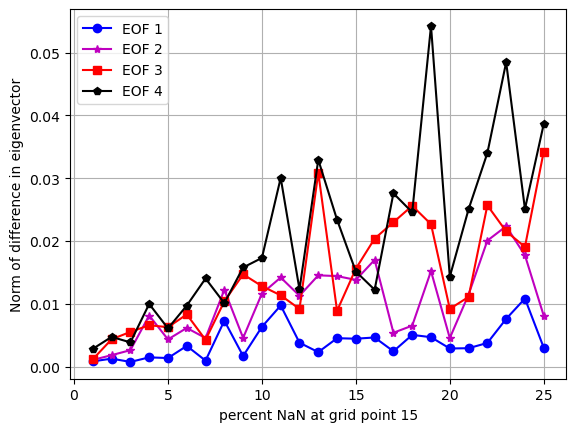

In [4]:
# Plot
plt.figure()
plt.clf()

plt.plot(np.arange(1, 26), mydiff1, 'bo-', label='EOF 1')
plt.plot(np.arange(1, 26), mydiff2, 'm*-', label='EOF 2')
plt.plot(np.arange(1, 26), mydiff3, 'rs-', label='EOF 3')
plt.plot(np.arange(1, 26), mydiff4, 'kp-', label='EOF 4')

plt.xlabel('percent NaN at grid point 15')
plt.ylabel('Norm of difference in eigenvector')
plt.legend(loc='upper left')
plt.grid(True)

plt.show()

In [5]:
myden.shape

(35, 1992)

In [9]:
myden[13:16]

array([[1025.85496555, 1025.6974079 , 1025.90958873, ..., 1025.71861258,
        1025.55596971, 1025.53389003],
       [1025.82596577, 1025.67341915, 1025.89638141, ..., 1025.69899012,
        1025.53305304, 1025.5127263 ],
       [1025.78526646, 1025.65043447, 1025.87929702, ..., 1025.67597729,
        1025.52224053, 1025.50553316]], shape=(3, 1992))

In [10]:
mydata[13:16]

array([[1025.85496555, 1025.6974079 , 1025.90958873, ..., 1025.71861258,
        1025.55596971, 1025.53389003],
       [          nan,           nan,           nan, ...,           nan,
                  nan,           nan],
       [1025.78526646, 1025.65043447, 1025.87929702, ..., 1025.67597729,
        1025.52224053, 1025.50553316]], shape=(3, 1992))

In [11]:
mydata[14]

array([nan, nan, nan, ..., nan, nan, nan], shape=(1992,))

In [15]:
np.where(~np.isnan(mydata[14]))[0]

array([  12,   20,   26,   32,   46,   50,   55,   69,   88,   90,   92,
        101,  109,  119,  126,  130,  143,  144,  160,  174,  189,  197,
        234,  240,  245,  259,  260,  272,  296,  302,  326,  339,  356,
        381,  395,  409,  428,  430,  454,  456,  472,  484,  492,  506,
        514,  519,  525,  537,  544,  546,  547,  549,  579,  585,  599,
        609,  626,  638,  639,  641,  644,  669,  683,  692,  696,  704,
        706,  722,  726,  736,  743,  748,  751,  753,  762,  793,  795,
        801,  808,  828,  839,  847,  851,  896,  904,  906,  915,  925,
        936,  954,  965,  968,  976,  997, 1000, 1030, 1049, 1054, 1066,
       1076, 1078, 1081, 1097, 1110, 1114, 1116, 1118, 1123, 1137, 1138,
       1141, 1146, 1150, 1169, 1177, 1179, 1186, 1188, 1214, 1224, 1239,
       1247, 1266, 1268, 1271, 1273, 1286, 1287, 1289, 1315, 1332, 1334,
       1349, 1370, 1372, 1380, 1390, 1391, 1393, 1402, 1406, 1422, 1425,
       1431, 1434, 1438, 1444, 1463, 1473, 1479, 14

In [17]:
mydata.shape, mydata_clean.shape

((35, 1992), (199, 35))